In [40]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "final_dataset.csv"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
BEST_MODEL_PATH = MODELS_DIR / "best_model.pkl"
VECTORIZER_PATH = MODELS_DIR / "vectorizer.pkl"
RESULTS_PATH = OUTPUTS_DIR / "model_results.csv"
CHART_PATH = OUTPUTS_DIR / "model_comparison.png"
ERROR_ANALYSIS_PATH = OUTPUTS_DIR / "error_analysis.csv"

FEATURE_COLUMNS = ["skills", "experience_level", "education_level"]
REQUIRED_COLUMNS = FEATURE_COLUMNS + ["label"]

In [41]:
# Load and validate dataset
df = pd.read_csv(DATA_PATH)

missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {', '.join(missing)}")
if df["label"].isna().any():
    raise ValueError(f"Found {df['label'].isna().sum()} empty labels")

print(f"Dataset: {df.shape[0]} rows, {df['label'].nunique()} classes")
print(df["label"].value_counts())

Dataset: 1262 rows, 10 classes
label
Backend Developer        167
Cybersecurity Analyst    139
Data Analyst             127
Frontend Developer       126
Data Scientist           123
Data Engineer            122
Mobile Developer         121
Full Stack Developer     119
QA Engineer              110
DevOps Engineer          108
Name: count, dtype: int64


In [42]:
# Feature engineering — combine text features (job_title excluded to prevent data leakage)
text_features = df[FEATURE_COLUMNS].fillna("").astype(str)
df["combined_text"] = text_features.agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()

# Train/test split with stratification
X_text, y = df["combined_text"], df["label"].astype(str)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# TF-IDF vectorization (fit only on train set)
vectorizer = TfidfVectorizer(
    lowercase=True, stop_words="english", ngram_range=(1, 2),
    max_features=5000, min_df=2, sublinear_tf=True
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1009, 1170), Test: (253, 1170)


In [43]:
# Define models
models = {
    "Dummy Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE, class_weight="balanced"),
    "Linear SVM": LinearSVC(C=1.0, random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

# Safe CV setup
min_class = int(y_train.value_counts().min())
safe_cv = min(5, min_class)
cv_strategy = StratifiedKFold(n_splits=safe_cv, shuffle=True, random_state=RANDOM_STATE) if safe_cv >= 2 else None
print(f"CV folds: {safe_cv}")

CV folds: 5


In [44]:
# Train and evaluate base models
def eval_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    m = eval_metrics(y_test, y_pred)
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="f1_macro").mean() if cv_strategy else np.nan
    m.update({"Model": name, "CV Macro F1": cv_f1, "Best Params": "", "Model Type": "base"})
    results.append(m)
    trained_models[name] = model
    print(f"{name:25s} | Acc={m['Accuracy']:.4f} | F1={m['Macro F1']:.4f} | CV={cv_f1:.4f}")

Dummy Most Frequent       | Acc=0.1344 | F1=0.0237 | CV=0.0233
Multinomial NB            | Acc=0.7787 | F1=0.7929 | CV=0.7791
Complement NB             | Acc=0.8103 | F1=0.8149 | CV=0.8035
Logistic Regression       | Acc=0.8379 | F1=0.8421 | CV=0.8428
Linear SVM                | Acc=0.8617 | F1=0.8612 | CV=0.8530
Random Forest             | Acc=0.8498 | F1=0.8517 | CV=0.8506
KNN                       | Acc=0.7945 | F1=0.7959 | CV=0.7651


In [45]:
# GridSearchCV for selected models
if cv_strategy:
    tuning_specs = {
        "Logistic Regression Tuned": {
            "estimator": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
            "param_grid": {"C": [0.01, 0.1, 1, 5, 10]},
        },
        "Linear SVM Tuned": {
            "estimator": LinearSVC(random_state=RANDOM_STATE, class_weight="balanced"),
            "param_grid": {"C": [0.01, 0.1, 1, 5, 10]},
        },
        "KNN Tuned": {
            "estimator": KNeighborsClassifier(),
            "param_grid": {"n_neighbors": [3, 5, 7, 9]},
        },
    }

    for name, spec in tuning_specs.items():
        gs = GridSearchCV(spec["estimator"], spec["param_grid"], scoring="f1_macro", cv=cv_strategy)
        gs.fit(X_train, y_train)
        y_pred = gs.best_estimator_.predict(X_test)
        m = eval_metrics(y_test, y_pred)
        m.update({"Model": name, "CV Macro F1": gs.best_score_, "Best Params": gs.best_params_, "Model Type": "tuned"})
        results.append(m)
        trained_models[name] = gs.best_estimator_
        print(f"{name:25s} | Acc={m['Accuracy']:.4f} | F1={m['Macro F1']:.4f} | CV={gs.best_score_:.4f} | {gs.best_params_}")

Logistic Regression Tuned | Acc=0.8735 | F1=0.8738 | CV=0.8649 | {'C': 10}
Linear SVM Tuned          | Acc=0.8893 | F1=0.8890 | CV=0.8575 | {'C': 5}
KNN Tuned                 | Acc=0.8182 | F1=0.8193 | CV=0.7797 | {'n_neighbors': 3}


In [46]:
# Build and display results table
results_df = pd.DataFrame(results)[
    ["Model", "Model Type", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "CV Macro F1", "Best Params"]
].sort_values(["Macro F1", "CV Macro F1"], ascending=False).reset_index(drop=True)

# Select best model by Macro F1 (tie-break by CV)
top_f1 = results_df["Macro F1"].max()
candidates = results_df[results_df["Macro F1"] >= top_f1 - 0.001].copy()
candidates["_cv"] = candidates["CV Macro F1"].fillna(-1)
best_row = candidates.sort_values(["_cv", "Macro F1"], ascending=False).iloc[0]
best_name = best_row["Model"]
best_model = trained_models[best_name]

print(f"\nBest model: {best_name} (Macro F1: {best_row['Macro F1']:.4f})")
results_df


Best model: Linear SVM Tuned (Macro F1: 0.8890)


,Model,Model Type,Accuracy,Macro Precision,Macro Recall,Macro F1,CV Macro F1,Best Params
0,Linear SVM Tuned,tuned,0.889328,0.895617,0.887608,0.889021,0.857496,{'C': 5}
1,Logistic Regression Tuned,tuned,0.873518,0.882100,0.871869,0.873759,0.864864,{'C': 10}
2,Linear SVM,base,0.861660,0.868967,0.860216,0.861219,0.852988,
3,Random Forest,base,0.849802,0.864116,0.846530,0.851655,0.850568,
4,Logistic Regression,base,0.837945,0.851425,0.840497,0.842109,0.842790,
5,KNN Tuned,tuned,0.818182,0.832007,0.815552,0.819269,0.779726,{'n_neighbors': 3}
6,Complement NB,base,0.810277,0.854671,0.807307,0.814864,0.803462,
7,KNN,base,0.794466,0.809815,0.796684,0.795907,0.765093,
8,Multinomial NB,base,0.778656,0.855474,0.769917,0.792891,0.779096,
9,Dummy Most Frequent,base,0.134387,0.013439,0.100000,0.023693,0.023291,


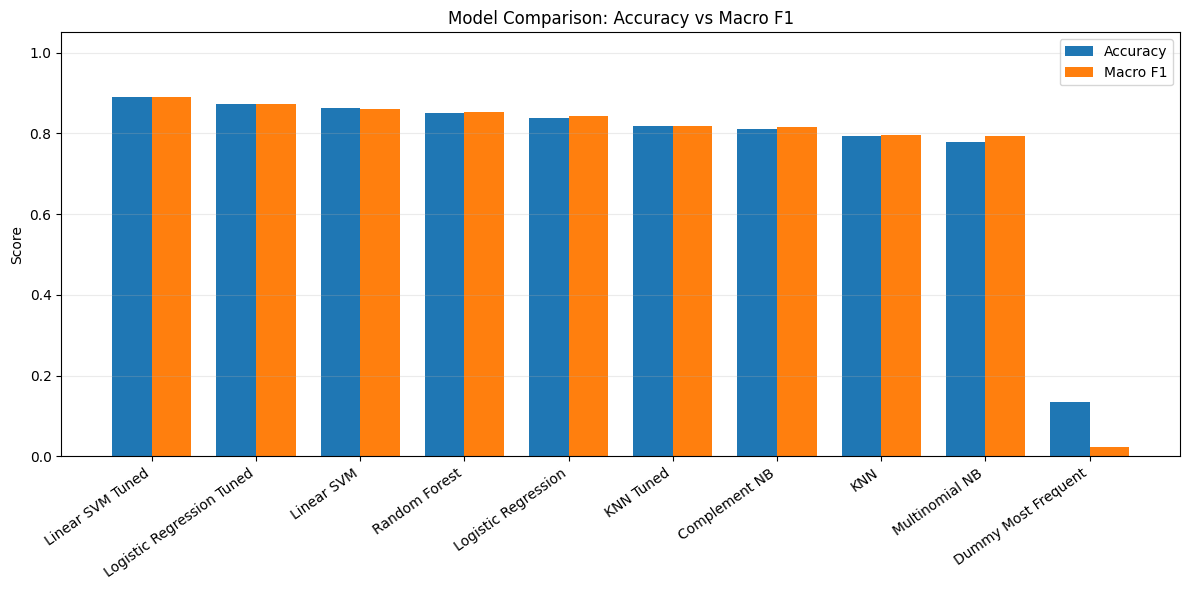

In [47]:
# Model comparison chart
chart_df = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)
x = np.arange(len(chart_df))
w = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - w/2, chart_df["Accuracy"], width=w, label="Accuracy")
plt.bar(x + w/2, chart_df["Macro F1"], width=w, label="Macro F1")
plt.xticks(x, chart_df["Model"], rotation=35, ha="right")
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs Macro F1")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(CHART_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [48]:
# Error analysis
best_y_pred = best_model.predict(X_test)
base_cols = [c for c in ["job_id", "job_title", "skills", "experience_level", "education_level"] if c in df.columns]
class_counts = df["label"].astype(str).value_counts()

def infer_reason(true_l, pred_l, text):
    pair = {true_l, pred_l}
    rare = set(class_counts[class_counts < 20].index)
    if true_l in rare: return "True class has few examples"
    if pair <= {"Backend Developer", "Frontend Developer", "Full Stack Developer"}: return "Overlapping web dev vocabulary"
    if pair <= {"Data Analyst", "Data Scientist", "Data Engineer"}: return "Overlapping data role vocabulary"
    if pair <= {"Backend Developer", "DevOps Engineer", "Cybersecurity Analyst"}: return "Overlapping infra/security terms"
    if pair <= {"Frontend Developer", "Mobile Developer"}: return "Overlapping client-side terms"
    if pair <= {"QA Engineer", "Backend Developer", "DevOps Engineer"}: return "Overlapping testing/backend terms"
    if len(str(text).split()) < 8: return "Short text sample"
    return "Skills shared across multiple roles"

error_df = df.loc[X_test_text.index, base_cols].copy()
error_df["combined_text"] = X_test_text.values
error_df["true_label"] = y_test.values
error_df["predicted_label"] = best_y_pred
error_df = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()
if not error_df.empty:
    error_df["possible_reason"] = error_df.apply(lambda r: infer_reason(r["true_label"], r["predicted_label"], r["combined_text"]), axis=1)

print(f"Errors: {len(error_df)} / {len(y_test)} test samples")
error_df.head(10)

Errors: 28 / 253 test samples


,job_id,job_title,skills,experience_level,education_level,combined_text,true_label,predicted_label,possible_reason
1110,31a943a2,Middle DWH/SQL разработчик,"python, sql, postgresql, ci/cd, git",От 1 года до 3 лет,Not Specified,"python, sql, postgresql, ci/cd, git От 1 года ...",Data Engineer,QA Engineer,Skills shared across multiple roles
923,39747052,Data Engineer,"python, sql, postgresql",От 1 года до 3 лет,Not Specified,"python, sql, postgresql От 1 года до 3 лет Not...",Data Engineer,Data Analyst,Overlapping data role vocabulary
583,aee2bc17,Senior Java-разработчик,java,От 3 до 6 лет,Not Specified,java От 3 до 6 лет Not Specified,Backend Developer,Mobile Developer,Skills shared across multiple roles
992,94ccdb58,"AI-first Full Stack Developer (Node.js, React,...","javascript, typescript, react, postgresql, docker",Более 6 лет,Not Specified,"javascript, typescript, react, postgresql, doc...",Full Stack Developer,Frontend Developer,Overlapping web dev vocabulary
569,7c51f16b,Senior Data Scientist,"python, sql, ci/cd",От 1 года до 3 лет,Высшее образование,"python, sql, ci/cd От 1 года до 3 лет Высшее о...",Data Scientist,Data Analyst,Overlapping data role vocabulary
763,4ccaf95c,QA Manual Trainee,sql,Более 6 лет,Not Specified,sql Более 6 лет Not Specified,QA Engineer,Data Analyst,Short text sample
960,627127bb,Видеограф / Motion-дизайнер (Full-stack контен...,figma,От 1 года до 3 лет,Not Specified,figma От 1 года до 3 лет Not Specified,Full Stack Developer,QA Engineer,Skills shared across multiple roles
706,a7f31567,Middle Android разработчик,"java, javascript, ci/cd",От 1 года до 3 лет,Not Specified,"java, javascript, ci/cd От 1 года до 3 лет Not...",Mobile Developer,QA Engineer,Skills shared across multiple roles
926,bf970cd5,Manager / Data Engineer / Analyst,sql,От 1 года до 3 лет,Not Specified,sql От 1 года до 3 лет Not Specified,Data Engineer,Data Analyst,Overlapping data role vocabulary
879,29b2ee02,QA Engineer Junior (Mobile),mysql,От 1 года до 3 лет,Not Specified,mysql От 1 года до 3 лет Not Specified,QA Engineer,Backend Developer,Overlapping testing/backend terms


In [49]:
# Save all artifacts
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, BEST_MODEL_PATH)
joblib.dump(vectorizer, VECTORIZER_PATH)
results_df.to_csv(RESULTS_PATH, index=False)
error_df.to_csv(ERROR_ANALYSIS_PATH, index=False)

print(f"Saved: {BEST_MODEL_PATH}")
print(f"Saved: {VECTORIZER_PATH}")
print(f"Saved: {RESULTS_PATH}")
print(f"Saved: {CHART_PATH}")
print(f"Saved: {ERROR_ANALYSIS_PATH}")

Saved: /home/duklet/AI_Project/ML/models/best_model.pkl
Saved: /home/duklet/AI_Project/ML/models/vectorizer.pkl
Saved: /home/duklet/AI_Project/ML/outputs/model_results.csv
Saved: /home/duklet/AI_Project/ML/outputs/model_comparison.png
Saved: /home/duklet/AI_Project/ML/outputs/error_analysis.csv
